# QHARM Corrected Modeling

Objective: repeat the `5_Modeling.ipynb` CatBoost validation with QHARM-corrected barriers and compare model behavior before and after the thermochemical correction.

This notebook keeps the same descriptor construction and 5-fold split as the original modeling notebook. It tests three scenarios:

- original target + original descriptors
- QHARM target + original descriptors
- QHARM target + QHARM reaction-energy feature, replacing the first descriptor column

## Plan

- Load descriptor pickle files and merge QHARM barrier targets by reaction key.
- Build the original feature matrix exactly as in `5_Modeling.ipynb`.
- Replace the first feature with `delta_g_rxn_qharm_kcal` for the self-consistent QHARM-feature scenario.
- Run or reload 5-fold CatBoost validation.
- Compare metrics, prediction scatter, and feature importances.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

from DFTStructureGenerator.descriptor import DUPLICATE_CL_IDS, dataframe_to_descriptors, load_descriptor_maps
from DFTStructureGenerator.project_paths import DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR
from DFTStructureGenerator.thermochemistry import database_path, load_reaction_dataset

OUTDIR = Path("output/jupyter-notebook")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTDIR.mkdir(parents=True, exist_ok=True)

MODEL_ITERATIONS = 10000
RANDOM_STATE = 0
FORCE_RETRAIN = False
# Thermochemistry switch: QHARM is the revised default; False collapses the selected scenario to RRHO.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
SELECTED_BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
SELECTED_REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"

plt.rcParams.update({"font.family": "Arial", "font.size": 8, "axes.linewidth": 0.8})

## Load Data and Build Features

In [2]:
reaction_df = load_reaction_dataset(TS_DATA_DIR / "Borane_all.csv", use_qharm=False)
selected_df = load_reaction_dataset(
    TS_DATA_DIR / "Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
)
reaction_df["key"] = reaction_df.apply(
    lambda r: f"B_{int(r['B_Index']):05}_LB_{int(r['N_Index']):05}_Cl_{int(r['Cl_Index']):05}",
    axis=1,
)
selected_df["key"] = selected_df.apply(
    lambda r: f"B_{int(r['B_Index']):05}_LB_{int(r['N_Index']):05}_Cl_{int(r['Cl_Index']):05}",
    axis=1,
)
selected_values = selected_df[["key", SELECTED_BARRIER_COLUMN, SELECTED_REACTION_ENERGY_COLUMN]].rename(
    columns={
        SELECTED_BARRIER_COLUMN: "barrier_qharm_kcal",
        SELECTED_REACTION_ENERGY_COLUMN: "delta_g_rxn_qharm_kcal",
    }
)
model_df = reaction_df.merge(selected_values, on="key", how="inner", validate="one_to_one")

B_N_des_map, Cl_des_map = load_descriptor_maps(
    DESCRIPTOR_DIR / "BNdes_new2.pkl",
    DESCRIPTOR_DIR / "Cldes_new2.pkl",
)

X_original = dataframe_to_descriptors(
    model_df,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=DUPLICATE_CL_IDS,
    show_progress=False,
    reaction_energy_column="deltaG(kcal/mol)",
)
X_qharm_rxn = X_original.copy()
X_qharm_rxn[:, 0] = model_df["delta_g_rxn_qharm_kcal"].to_numpy(dtype=float)

y_original = model_df["deltaGa(kcal/mol)"].to_numpy(dtype=float)
y_qharm = model_df["barrier_qharm_kcal"].to_numpy(dtype=float)

print("Rows:", len(model_df))
print("Feature matrix:", X_original.shape)
display(model_df[["deltaGa(kcal/mol)", "barrier_qharm_kcal", "deltaG(kcal/mol)", "delta_g_rxn_qharm_kcal"]].describe())

Rows: 9237
Feature matrix: (9237, 18)


,deltaGa(kcal/mol),barrier_qharm_kcal,deltaG(kcal/mol),delta_g_rxn_qharm_kcal
count,9237.000000,9237.000000,9237.000000,9237.000000
mean,21.005709,15.426717,-20.132210,-19.750904
std,6.345791,5.178058,10.008266,10.201556
min,0.300679,-3.385036,-63.428077,-64.300651
25%,16.226717,11.724975,-27.327123,-26.918227
50%,21.324527,15.345378,-19.159457,-18.836923
75%,25.660954,18.972021,-12.046306,-11.577965
max,53.647416,40.354847,-4.102595,-0.041187


## Model Helpers

In [3]:
try:
    from catboost import CatBoostRegressor
    MODEL_BACKEND = "CatBoostRegressor"
except Exception as exc:
    CatBoostRegressor = None
    MODEL_BACKEND = f"CatBoost unavailable: {type(exc).__name__}: {exc}"


def make_model():
    if CatBoostRegressor is None:
        raise RuntimeError(MODEL_BACKEND)
    return CatBoostRegressor(
        iterations=MODEL_ITERATIONS,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=RANDOM_STATE,
    )


def calc_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MSE": mean_squared_error(y_true, y_pred),
    }


scenarios = {
    "original_target_original_features": {
        "label": "Original target + original features",
        "X": X_original,
        "y": y_original,
        "target": "deltaGa(kcal/mol)",
    },
    "qharm_target_original_features": {
        "label": "QHARM target + original features",
        "X": X_original,
        "y": y_qharm,
        "target": "barrier_qharm_kcal",
    },
    "qharm_target_qharm_rxn_feature": {
        "label": "QHARM target + QHARM reaction-energy feature",
        "X": X_qharm_rxn,
        "y": y_qharm,
        "target": "barrier_qharm_kcal",
    },
}

print(MODEL_BACKEND)

CatBoost unavailable: ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


## Run or Reload 5-Fold Validation

In [4]:
METRICS_PATH = OUTDIR / "qh_model_cv_metrics.csv"
PRED_PATH = OUTDIR / "qh_model_cv_predictions.csv"


def run_cv(name, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pred = np.zeros_like(y, dtype=float)
    fold_rows = []
    t0 = time.perf_counter()
    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        model = make_model()
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        pred[test_idx] = y_pred
        row = {"scenario": name, "fold": fold, "train_size": len(train_idx), "test_size": len(test_idx)}
        row.update(calc_metrics(y[test_idx], y_pred))
        fold_rows.append(row)
        print(name, "fold", fold, row)
    total_s = time.perf_counter() - t0
    overall = {"scenario": name, "fold": "overall", "train_size": len(y), "test_size": len(y), "runtime_s": total_s}
    overall.update(calc_metrics(y, pred))
    return pred, pd.DataFrame(fold_rows + [overall])


if FORCE_RETRAIN or not (METRICS_PATH.exists() and PRED_PATH.exists()):
    predictions = {}
    metric_tables = []
    for name, cfg in scenarios.items():
        pred, metric_table = run_cv(name, cfg["X"], cfg["y"])
        predictions[name] = pred
        metric_tables.append(metric_table)
    metrics_df = pd.concat(metric_tables, ignore_index=True)
    metrics_df.to_csv(METRICS_PATH, index=False)

    pred_df = pd.DataFrame({
        "key": model_df["key"],
        "y_original": y_original,
        "y_qharm": y_qharm,
        "delta_qharm_minus_original": y_qharm - y_original,
        "pred_original_target_original_features": predictions["original_target_original_features"],
        "pred_qharm_target_original_features": predictions["qharm_target_original_features"],
        "pred_qharm_target_qharm_rxn_feature": predictions["qharm_target_qharm_rxn_feature"],
    })
    pred_df.to_csv(PRED_PATH, index=False)
else:
    metrics_df = pd.read_csv(METRICS_PATH)
    pred_df = pd.read_csv(PRED_PATH)

display(metrics_df.loc[metrics_df["fold"].astype(str).eq("overall")])

,scenario,fold,train_size,test_size,R2,MAE,RMSE,MSE,runtime_s
5,original_target_original_features,overall,9237,9237,0.906096,1.391403,1.944484,3.781018,80.916595
11,qharm_target_original_features,overall,9237,9237,0.881367,1.295918,1.783389,3.180477,79.305680
17,qharm_target_qharm_rxn_feature,overall,9237,9237,0.888847,1.256858,1.726248,2.979934,83.005817


## Feature Importances

In [5]:
IMPORTANCE_PATH = OUTDIR / "qh_model_feature_importance.csv"

feature_names = [
    "deltaG_rxn", "BN_B_spin", "BN_B_Hirshfeld_charge", "BN_BN_distance", "BN_SOMO",
    "BNCl_B_Hirshfeld_charge", "BNCl_Cl_Hirshfeld_charge", "BNCl_BCl_distance", "BNCl_LUMO", "BNCl_percent_buried_volume",
    "CCl_Cl_Hirshfeld_charge", "CCl_C_Hirshfeld_charge", "CCl_CCl_distance", "CCl_LUMO", "CCl_percent_buried_volume",
    "C_radical_spin", "C_radical_C_Hirshfeld_charge", "C_radical_SOMO",
]

if FORCE_RETRAIN or not IMPORTANCE_PATH.exists():
    importance_rows = []
    for name, cfg in scenarios.items():
        model = make_model()
        model.fit(cfg["X"], cfg["y"])
        for feature, importance in zip(feature_names, model.feature_importances_):
            importance_rows.append({"scenario": name, "feature": feature, "importance": importance})
    importance_df = pd.DataFrame(importance_rows)
    importance_df.to_csv(IMPORTANCE_PATH, index=False)
else:
    importance_df = pd.read_csv(IMPORTANCE_PATH)

display(
    importance_df
    .sort_values(["scenario", "importance"], ascending=[True, False])
    .groupby("scenario")
    .head(6)
)

,scenario,feature,importance
0,original_target_original_features,deltaG_rxn,28.482734
12,original_target_original_features,CCl_CCl_distance,9.409148
1,original_target_original_features,BN_B_spin,9.222535
8,original_target_original_features,BNCl_LUMO,8.217125
4,original_target_original_features,BN_SOMO,6.415347
17,original_target_original_features,C_radical_SOMO,6.011226
18,qharm_target_original_features,deltaG_rxn,27.516136
30,qharm_target_original_features,CCl_CCl_distance,8.237084
26,qharm_target_original_features,BNCl_LUMO,7.540612
22,qharm_target_original_features,BN_SOMO,6.785294


## Plot Model Validation

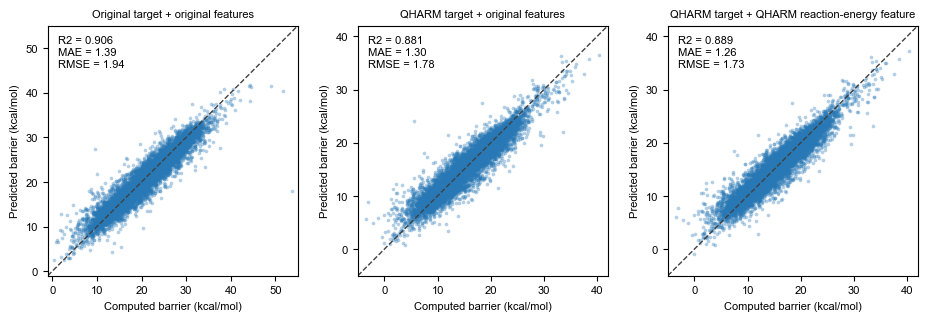

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.1), constrained_layout=True)

plot_cfgs = [
    ("original_target_original_features", "y_original", "pred_original_target_original_features"),
    ("qharm_target_original_features", "y_qharm", "pred_qharm_target_original_features"),
    ("qharm_target_qharm_rxn_feature", "y_qharm", "pred_qharm_target_qharm_rxn_feature"),
]

for ax, (scenario, y_col, pred_col) in zip(axes, plot_cfgs):
    y_true = pred_df[y_col].to_numpy()
    y_pred = pred_df[pred_col].to_numpy()
    ax.scatter(y_true, y_pred, s=7, alpha=0.35, linewidths=0, color="#2878b5")
    lo = np.floor(min(y_true.min(), y_pred.min()) - 1)
    hi = np.ceil(max(y_true.max(), y_pred.max()) + 1)
    ax.plot([lo, hi], [lo, hi], color="0.25", lw=1, ls="--")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    metric_row = metrics_df.loc[
        metrics_df["scenario"].eq(scenario) & metrics_df["fold"].astype(str).eq("overall")
    ].iloc[0]
    ax.text(
        0.04,
        0.96,
        f"R2 = {metric_row.R2:.3f}\nMAE = {metric_row.MAE:.2f}\nRMSE = {metric_row.RMSE:.2f}",
        transform=ax.transAxes,
        va="top",
    )
    ax.set_title(scenarios[scenario]["label"], fontsize=8)
    ax.set_xlabel("Computed barrier (kcal/mol)")
    ax.set_ylabel("Predicted barrier (kcal/mol)")

fig.savefig(FIGURE_DIR / "Revision_QH_Model_Validation.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "qh_model_validation.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot Feature Importance Changes

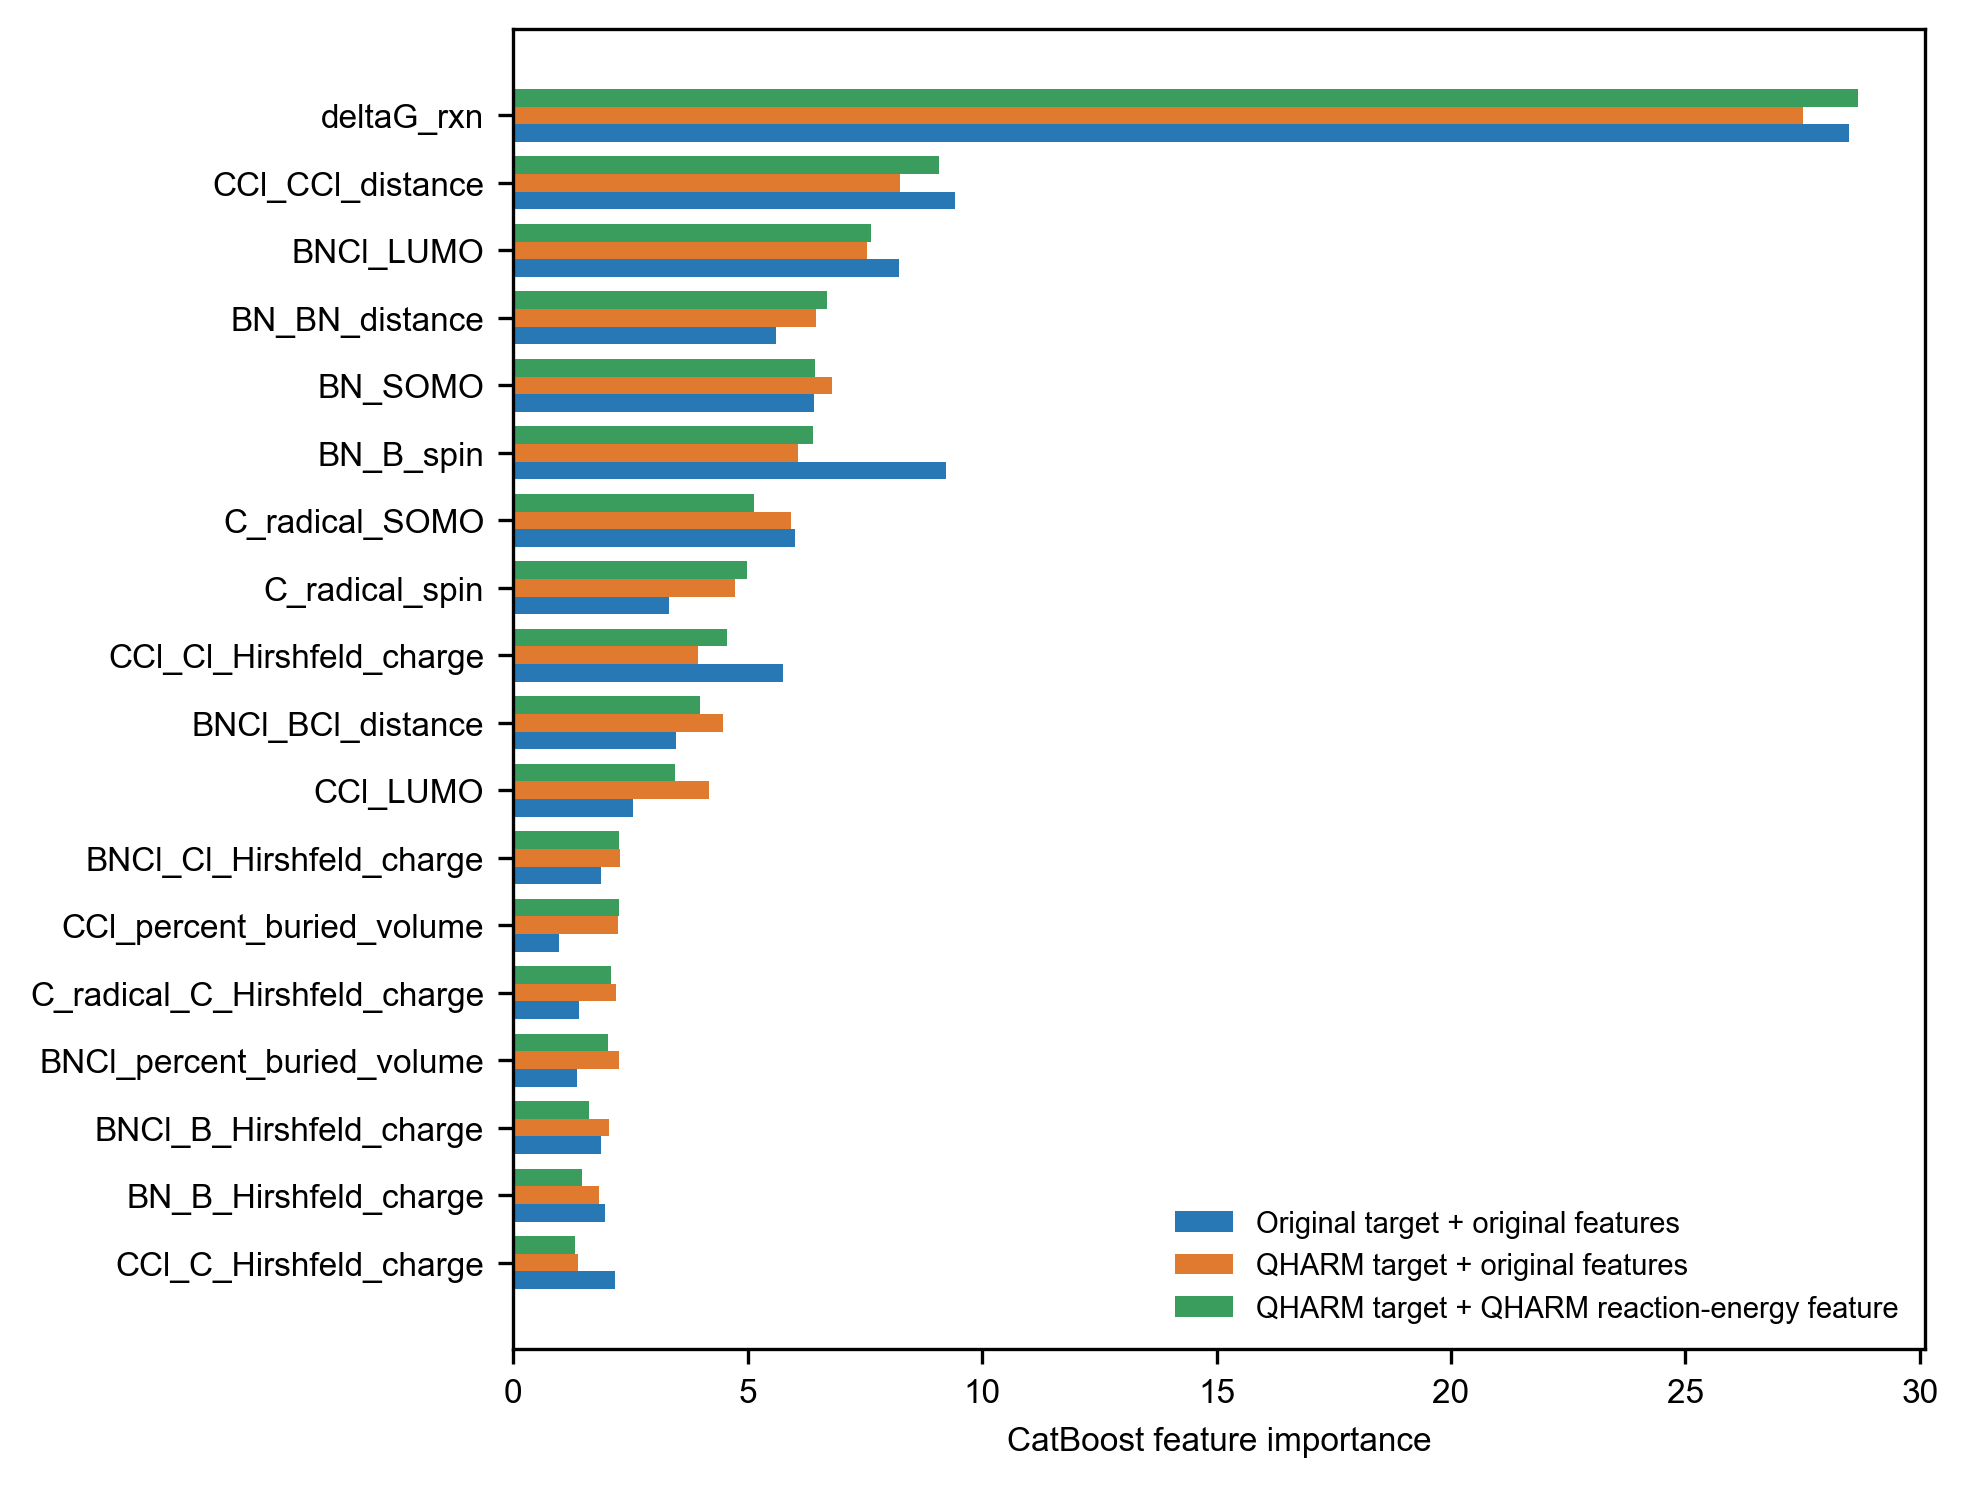

In [7]:
pivot_importance = importance_df.pivot(index="feature", columns="scenario", values="importance").fillna(0)
order = pivot_importance["qharm_target_qharm_rxn_feature"].sort_values().index

fig, ax = plt.subplots(figsize=(6.6, 5.0), dpi=300)
ypos = np.arange(len(order))
width = 0.26
for offset, name, color in [
    (-width, "original_target_original_features", "#2878b5"),
    (0, "qharm_target_original_features", "#e07a2f"),
    (width, "qharm_target_qharm_rxn_feature", "#3a9d5d"),
]:
    ax.barh(
        ypos + offset,
        pivot_importance.loc[order, name],
        height=width,
        label=scenarios[name]["label"],
        color=color,
    )
ax.set_yticks(ypos)
ax.set_yticklabels(order)
ax.set_xlabel("CatBoost feature importance")
ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_QH_Model_Feature_Importance.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "qh_model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Notes

The QHARM target has a smaller absolute range than the original barrier distribution, so MAE/RMSE decrease even when R2 decreases slightly. The self-consistent QHARM reaction-energy feature recovers part of the R2 drop and gives the lowest MAE among the three tested scenarios.